In [43]:
!pip install kagglehub
!pip install tensorflow
!pip install torch torchvision

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: C:\Users\guhen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: C:\Users\guhen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: C:\Users\guhen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


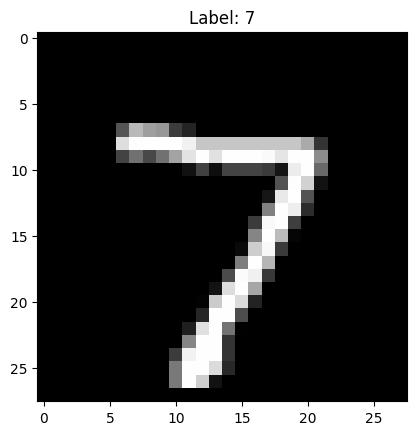

In [44]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import torch

# Baixa automaticamente e carrega
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Visualizar uma imagem
plt.imshow(x_test[0], cmap='gray')
plt.title(f'Label: {y_test[0]}')
plt.show()


KeyboardInterrupt: 

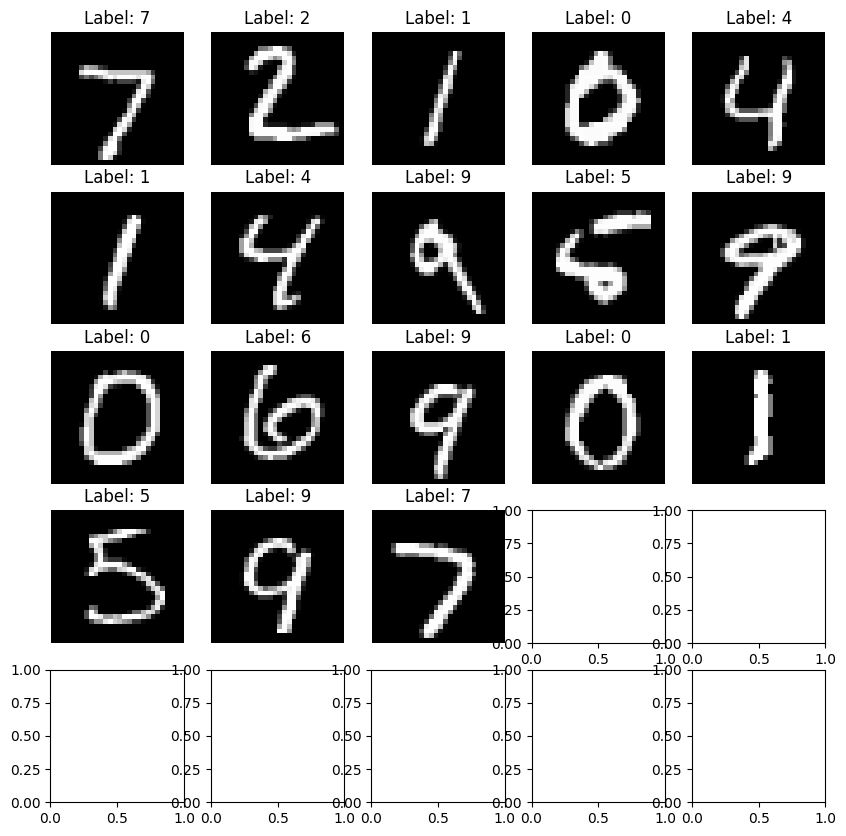

In [45]:
# Número de imagens a mostrar (por exemplo, 25 em um grid 5x5)
num_images = 30
rows = cols = int(num_images ** 0.5)

# Plotar um grid de imagens do conjunto de teste
fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(tf.keras.datasets.mnist.load_data()[1][0][i], cmap='gray')
    ax.set_title(f"Label: {tf.keras.datasets.mnist.load_data()[1][1][i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Normalização: converte os valores para float e divide por 255
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential([
    Flatten(input_shape=(28, 28)),          # Entrada 28x28 pixels
    Dense(128, activation='relu'),          # Camada oculta
    Dense(64, activation='relu'),           # Outra camada oculta
    Dense(10, activation='softmax')         # Saída com 10 classes (0 a 9)
])


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(x_train, y_train, epochs=30, validation_split=0.1)


Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8726 - loss: 0.4314 - val_accuracy: 0.9690 - val_loss: 0.1128
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9660 - loss: 0.1122 - val_accuracy: 0.9727 - val_loss: 0.0912
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9775 - loss: 0.0735 - val_accuracy: 0.9770 - val_loss: 0.0825
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9833 - loss: 0.0520 - val_accuracy: 0.9773 - val_loss: 0.0808
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9882 - loss: 0.0377 - val_accuracy: 0.9750 - val_loss: 0.0880
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9894 - loss: 0.0315 - val_accuracy: 0.9752 - val_loss: 0.1031
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9915 - loss: 0.0263 - val_accuracy: 0.9753 - val_loss: 0.1052
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9922 - loss: 0.0227 - 

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'\nTest Accuracy: {test_acc:.4f}')


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9742 - loss: 0.1946

Test Accuracy: 0.9782


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


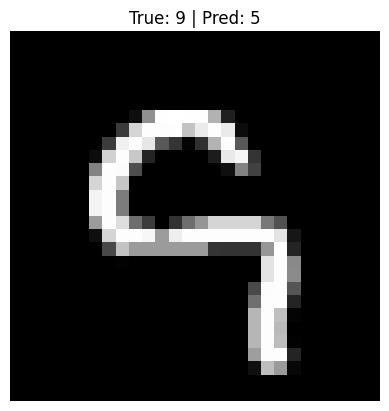

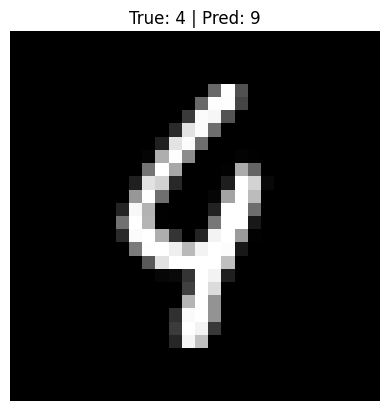

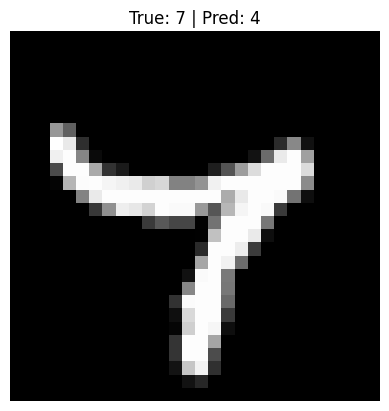

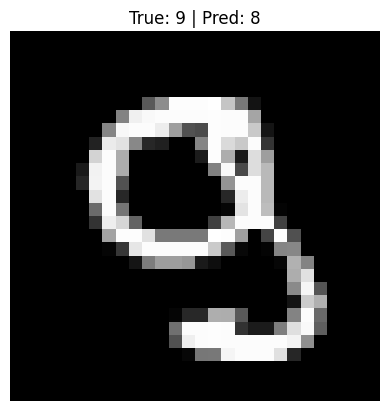

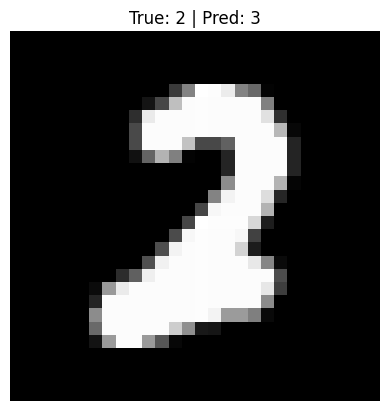

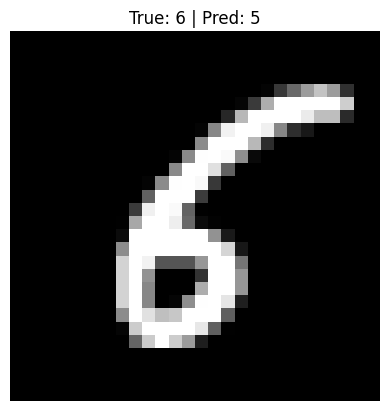

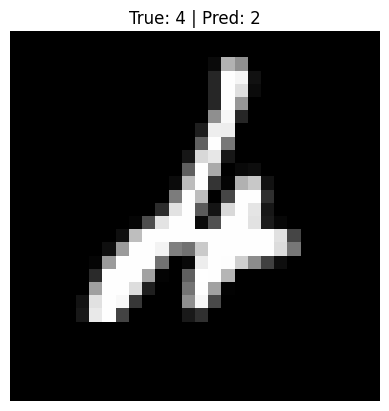

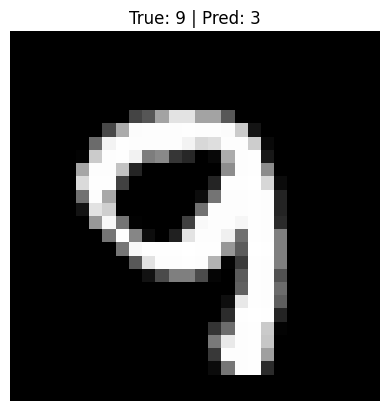

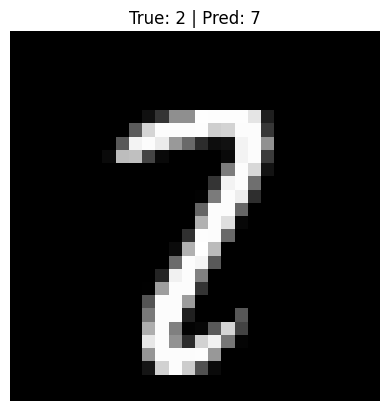

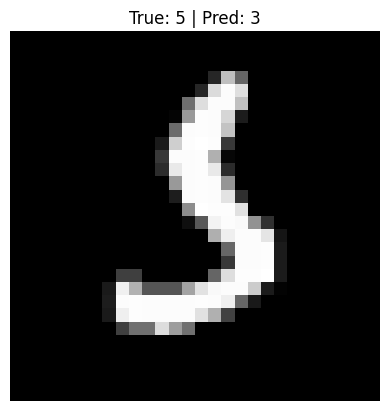

In [101]:
import numpy as np

predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

# Encontra os índices dos erros
errors = np.where(predicted_labels != y_test)[0]

# Mostra os 10 primeiros erros
for i in errors[:10]:
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"True: {y_test[i]} | Pred: {predicted_labels[i]}")
    plt.axis('off')
    plt.show()


In [102]:
!pip install opencv-python


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: C:\Users\guhen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [130]:
import cv2
import numpy as np

# Carregar a imagem em escala de cinza
imagem = cv2.imread(r"C:\Users\guhen\programas\mnist\imagem_para_teste_paint.png", cv2.IMREAD_GRAYSCALE)

# Redimensionar para 28x28 pixels
imagem_redimensionada = cv2.resize(imagem, (28, 28))

# Inverter as cores: fundo preto e dígito branco
imagem_invertida = cv2.bitwise_not(imagem_redimensionada)

# Normalizar os pixels para o intervalo [0, 1]
imagem_normalizada = imagem_invertida / 255.0

# Ajustar as dimensões para o formato esperado pelo modelo
# Para TensorFlow/Keras: (1, 28, 28, 1)
imagem_final = imagem_normalizada.reshape(1, 28, 28, 1)


In [131]:
print(imagem)
print(imagem_redimensionada)
print(imagem_invertida)
print(imagem_final)
print(imagem_normalizada)

[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]
[[255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
  255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
  255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
  255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255   2 255 255 255 255 255 255 255 255 255
  255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255   0 255 255 255 255 255 255 255  26 255
  255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255  66   0 255 255 255 255 255 255  67   1 255
  255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255   1   0 255 255 255 255 255 255  34   2 255
  255 255 255 255 255 255 255 25

In [132]:
print(imagem_final.shape)
print(type(imagem_final))
print(imagem_final.dtype)

(1, 28, 28, 1)
<class 'numpy.ndarray'>
float64


In [133]:
print(model.input_shape)


(None, 28, 28)


In [134]:
imagem_final = imagem_final.reshape(1, 28, 28)  # remove o canal


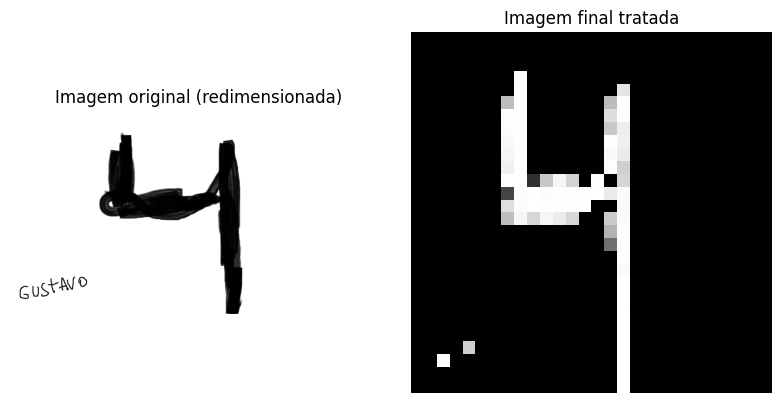

In [143]:
# Exibe lado a lado: original vs tratada
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Imagem original (28x28 redimensionada, ainda em tons de cinza)
axes[0].imshow(imagem, cmap='gray')
axes[0].set_title("Imagem original (redimensionada)")
axes[0].axis('off')

# Imagem após inversão + normalização (usada no modelo)
axes[1].imshow(imagem_final[0, :, :], cmap='gray')
axes[1].set_title("Imagem final tratada")
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [144]:
pred = model.predict(imagem_final)
classe = np.argmax(pred)
print("Classe prevista:", classe)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Classe prevista: 4


O teste funcionou muito bem !!